#**CRAW DATA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import subprocess

curl_cmd = r'''
curl 'https://www.traveloka.com/api/v2/ugc/review/consumption/v2/getReviews' \
  -H 'accept: */*' \
  -H 'accept-language: vi-VN,vi;q=0.9,fr-FR;q=0.8,fr;q=0.7,en-US;q=0.6,en;q=0.5' \
  -H 'content-type: application/json' \
  -b '_fbp=fb.1.1769614419266.440204108240900240; _gcl_au=1.1.593404946.1769614420; _tt_enable_cookie=1; _ttp=01KG2KT9PBQ518Y1PBDGVAYF27_.tt.1; _fwb=3p682snTAhF7TNxyDKmDy.1769614420725; _cs_ex=1760605804; _cs_c=1; __lt__cid=fd4cc0ea-7aa1-4e62-9b67-1080e76c4542; _yjsu_yjad=1769614421.6e36c347-ca77-4182-aafb-f0eef3d83026; _ly_su=1769614421.6e36c347-ca77-4182-aafb-f0eef3d83026; clientSessionId=T1-web.01KGQ6YCJ0455MF9GV9RT2KCGJ; tv_cs=1; tv-repeat-visit=true; countryCode=VN; _gcl_gs=2.1.k1$i1770305564$u102026180; __lt__sid=dc69289d-05c1939d; _gid=GA1.2.319763160.1770305567; tv_mcc_id=01KGQ6YEH5QWZ4HC6KYSGMRB09; g_state={"i_l":0,"i_ll":1770305572370,"i_e":{"enable_itp_optimization":0}}; tv_user={"authorizationLevel":"500","id":"273434256"}; _gac_UA-29776811-12=1.1770305582.Cj0KCQiAnJHMBhDAARIsABr7b87nfjt_gGOiCo4nec8ftOekukkIFXIgMAt6V6nPGHzSigQvXP3rfzkaAu8QEALw_wcB; _gcl_aw=GCL.1770305623.Cj0KCQiAnJHMBhDAARIsABr7b87nfjt_gGOiCo4nec8ftOekukkIFXIgMAt6V6nPGHzSigQvXP3rfzkaAu8QEALw_wcB; amp_f4354c=lgW5pvA46nfEtU5nnPoAHI...1jgn6udig.1jgn71rt4.0.4.4; __rtbh.lid=%7B%22eventType%22%3A%22lid%22%2C%22id%22%3A%22g0t4AeytsZ9rurh5BsaA%22%2C%22expiryDate%22%3A%222027-02-05T15%3A34%3A39.561Z%22%7D; _ga=GA1.2.185480410.1769614421; wcs_bt=s_2cb982ada97c:1770305679; cto_bundle=I-xG6l9wQ1ElMkI4RHQlMkJMb0pyMmNtUE1RZDFOaFNoWFo3R1dzTDRTMGxvVU1TSG05bXhIR0MyTVBKR3hnWGx5bVlFYlg3WSUyQjl1MVF0N3pGcjBLMU1sczdoeHNPbWxwT1N6RUFLdVE0Y2xlJTJCd1QlMkZzUjJIN3Jha1oxMW92NEQ5ViUyQk50dzZPOE53dkNtSTYlMkZUV3dOcWVPZnFaTmtxdyUzRCUzRA; _ga_RSRSMMBH0X=GS2.1.s1770305567$o5$g1$t1770305680$j11$l1$h258104512; ttcsid_CFNI0BRC77UEUGLEG00G=1770305595062::tSqWB6WqDziz69f_b4c-.3.1770305686075.1; datadome=lfh0cXZ5xz6mg6mlbtKZo66fjSHl4w_OI4ny2PRbkFwI_D2pit37gewnEVq~RWxWqWbAaCnNUxe2mtiwE9PULtgQ~M02t5FP~Zp1etsW7J5aM91x5lp_cDpvzaIuTw31; aws-waf-token=dc03440f-1763-44fe-9b73-09967cb1b4d4:NQoAnipvn/UDAAAA:cgUNHHpxJri3/vI+iyf4/M2MORgp4U+31P+bev4c7zE1RPNzpZqx7FUVqEu4Rwa7fbiiNyC/B03mYJAw/fDlzmbE4Rt69ZpG1xCREdKXYLJnlQdEk0wC/eJmJNnfmLsfM0dVWSNRiUCW0rOhNYwtYBxIHkbDA3rEvynK7jq62lBDOaleOJ332aCwhI/mB3wdvas=; tv_lt=1770307327725; amp_1a5adb=QX2uzpEUFU6gfMrIScZD0t...1jgn6udic.1jgn8kr1j.5h.4.5l; tvl=qgdHX7GvehrD9XH5a3S4PUiOJGezXQ9yizVaSxTklwrLYY64AE4apiD1qmHRGaV8gGAQoV6xR5wi1hxtboYegx0JoHbuxL9J5IDMykh7yrkDV+tDU0tOQZDC0wf5Bz7Ih8SGYm0D03zEW7S7g02l9zkAPbkMGQ6AJj+0Bs51j2ftJBXfGEyt2sEtTgV4IRGHScQCIEmV/+vSJUVlsj9PXIKrnez9pk7FDsIpIzRncFeZBVDugh6VlFzM5FyOMzwLO4joQ87vJKnQTQCImFFpAGCEdYEqZK+mG8yf8oes1f9S3cT047MDHw8NjroBycdAfhIvPYQKz9JN6XotHjyY4BicIcRda2on50AabPD1nMCAe3zlN4oAcX/aTCB0iimxlBUwBk3ywwYC+rcZbS47ZlzB+GOmQueNjMH1Si++CMLZwqpPhQGQOXwtSy7LciXbqK+uneW/GACFYbaHxjb8BLZiyW+SLE+KMyWl/gP3+Pu5foJEUOE63jiLspog9GK4vRgJd/8rV4DM743UlS2KUNQC3zQMtdz1VPZPMlU7Fq/72gZt5xaSSG/FRv7r0chF; tvs=qgdHX7GvehrD9XH5a3S4PXWKx93/3Xi103f/kPpnhg2NQFssR/Qj+XlD8T04IyjuUrc6H+WBXJ8wUnoZ8p0GoBHH2xkc8Ikyg6tkzonwNE3wDMhBdXxMxFXdCSvxFWgks8QwCeisMv+xT5Addzd3sf9B1IrVR7LfBENOQTdkl9KzJrc6tOJ53TTX8lJ9nKXucnxAlUsPGPCEhvFiDh8of0eNvNZ/7BEfQQHaDQaxiteVLEZP8aeXMGoYV2OzQkq+/0HUitVHst8EQ05BN2SX0oG6YV68HZIC986bmx7ZCKNuY7L9a9gt78z+RKs7SxLTn0e7lHZJPrh/C8N/EdNdfvLeBbL3a88BBjOJdPRJJyBU8t3KLtaLDcSHKofj6kxUQVlCePImAovb2iiMraW49H6dl9EyG0Bm8QPaJ+BVx+eRioqa5GsscrU1+zaB92BzPbZMoz9ubokUsi5bxHJwkfoSeuwKnpDu7quxM1+4r7nYkZoMqQe8ywmtaBvesn5viKVeDZ4DqWKlwqK9LuIAZGKN919tz4pcHtC7zWXO8cgqBz++x/+XPEWlhT9eaLGNl9X1Ako/0ku67Av2WqkXPBx1YgxnOeSEm0ZkEDZsZ3P/ex9Qtugvmn2FQqDyTdDkpRqqNcuq00KMpaxEnmmHBA==; tvo=L2FwaS92Mi91Z2MvcmV2aWV3L2NvbnN1bXB0aW9uL3YyL2dldFJldmlld3M=; _dd_s=rum=0&expire=1770308258411&logs=1&id=50732873-aed6-4b67-a17a-632d348476ec&created=1770305565594; ttcsid=1770305567297::W-TqpMa2GPSjXU3IgAcM.3.1770307358430.0::1.106394.118869::1791115.27.1347.1151::1642044.94.440; ttcsid_CUM82PBC77U4QKJNCRL0=1770305567297::r0GYo_i29P8-nESYAQ-_.3.1770307358430.1' \
  -H 'origin: https://www.traveloka.com' \
  -H 'priority: u=1, i' \
  -H 'referer: https://www.traveloka.com/vi-vn/hotel/detail?spec=05-02-2026.06-02-2026.1.1.HOTEL.9000000961953.Premier%20Pearl%20Hotel%20Vung%20Tau.2&loginPromo=1&prevSearchId=1856299984838749922&contexts=%7B%22inventoryRateKey%22%3A%22povEwB3ZzsU2C6pd%2B6MdU2B9D%2BXTtnp8xBPheXkh8zf7Zj7nhTn31ZNzbBPHY9dEfwxXnYiRzoxM4HX9sDmt9%2FAm1AYn3MeGz8Xcpq5hCtjlEYxDn%2BhbZgy96CBnQea9ojeZe8pUMPCFzjasbXTHzdbXEz9gSfCbUqDZdXop0HsV%2BPfAe57BmgIDH9PA%2BJjHUFcI0mHFBlMie%2BP8HC4ONWxwSiyKFTaNT8%2FJ76E3sAXbfXqddwjw75VPD5gzJN%2BusGPdKmqLCFoADPXD9yilD0jX5Qgb0%2F4Dq1Z2DEidaLbhiLDDTHrMEas4kUiGg%2BPkPKdRn8YjhYghjVSOQmzC%2B16fIMTqw3jCaofy7gHElXaTmCLnvvmHcvsFp46X2X%2B2ECdmHJ4uQBYLzR%2BuKXfaP6Yf%2Ff3TRvBN59OO434EplF1WDAp9S1hp8oMZqiTwOKaAVTtpl8LJKUtvHLuyDjwE%2FAm1AYn3MeGz8Xcpq5hCtgBVO2mXwskpS28cu7IOPATznAQDiZQbdXWL7WKias%2FLk3XJ7Vr9XsEITs5yDROczeqVwa6dhgL0376a2xbjamaSFYlMKIsZuNQhHPx%2B9HWrGcWmlZxr3ZWCc%2B%2FhNYHYDXUazQLRIr7PeVm7PEkXxcOMpCHbwvjiQ3lw39vUZ8rEnD5AfqdTY%2B58KO2zwwVZ6yXvIA3lVGg3j3PZ2p0MG4zgtNFrliQqp4wa4ohN4tWBJ9Fj3SfSyJq7FLL%2FbWOf0%2BvW3GtO1GX%2FXjtMVE%2Fz40hhU%2FmVyQmOi6L%2BbNqPtwNgxj8d1NAvGO%2BpR7zyIn5KMsXMUAd4%2BhO0wpIylhSLXCYD8mH1AR1eXTLntBuPIHMlwQLF4TsWV8H%2FGElcH2XoujmmVjIa4xDPxu1A5hWZC5O7kw9YIcZb%2BmA4Avz2HdOkWhQEWruTkWRZXyiN26%2FWo6OqsfS1BHq0IGYDFKn1WHdsUzTR9xp5Ss32s146B2DejQBuBYt0be%2F%2Fj1ezXVEYbPkyRJim0VAcOEcLypjjdxfIZpFZuNDDafzAE1edsIYDmplUMrBr49xllkAk0giKgOoCln3XJx8z8N5UcM4KhYiEHTm%2BcJ9vFQRMjqddNwo%2BwftINxVMwLXlS8R5nl1Q9yyyLifEhe5uAzaK3vEpY0Y9THUS3Vpd0NY7g43XBI%2Fmkj931akB3l4%2FPhEgWGig2%2Fgul7A%2F8yLZd8stStScxgNBRdU%2FbSMYEXnWl9FLMMqMUKiQLXoVmgKrneEjGrC2p0JjpjxsKBHzCtmeeIguk9ovYkUlyuYCkjreOru4h27OseblSvQzNqTPYRc%2Fy2ptKk1GYGtz%2FbZzipFa63MZe%2BAhJD6GNnYqmplb24M5qEVXy4lv2fuYnF%2BpqtuieM7lQoxjr1vunxwVXUTdLZTm1hw7CobCvUYXdcDFHxuiHM%2BC1M6l5M2GhbD8Zp9G2f01eJUpBVKxzgsHvo3GrLzikhSPnQqiu61DqvrGSzU5pAcXC5d%2FAi%2BFfzNSXMYJo3QaMuZL4GPDljKeClpxhs7L2m0dQR68AzEya8yGJ1vmJJtNIeQ7tnaIXZ5%2FeBEUvHW2kmXKBpUWyQxF0AYXRAGuKATFa6KXvnd%2BRz9LeKZ2thCueuYVkTf0L81iVRjpHor28g5DbOy4ErNrvUab%2FnggG%2FMazmjgsVM6BS0RNkJEUkODvhBYpnJzidIHYCijRC5rjSo32jpDheNkcPTlGA539h0orgnYxYntRu6cDCB8DiTis8hWRD43Ho3motm3miTtXjg1TnWCTyXFkNzXxTjk%2FKQmzAaoA%2BrprA3l013dAd9Q6TXbkc8L6wEe1abbVf3ENTe%2BkcOij6b%2Biso7EnxWds5HGlOTVv7Sww8UfmcFKTu8XMnpSyAvD1%2Bl1dOq0Ut9MySXvpZYuXAE1rxzAMbLBd9HCrMbXjJw2U979MvyvkDSFNF0zdgsaAM9uU5wzcIKI6j2wS4qFCLGLjHvSfwnetAOKlFtucsGddZfSW%2FAFf3qoDOyghnfek%2Bhl0okhEPaMrzS7tDiWICeBu59tPvN37VuahqtFFArXlUqgwObIwVoYoz2paA21xiiXMR6INU1%2BPoxtjAzlSUGYtGVqyk%2B72ICKqkrGBGnjSJLhiYA4SXYmFto%2FgCMbpTqD7CteGrHHFoY%2Fq%2FvdP3nfWyGFYyRTdmnIxprYdkelC9pRWRBFmvG7VFNo8ANPscTzzIlTUFptT7kExXUScWsaXkT1rQDAm0ZFJir6EhlU4ZLUeqHFwLY0XaY8Aj5kBlEp7sJPSSFL0%3D%22%7D&iuid=40d727ba-4b26-4455-b4d1-820a24c04371' \
  -H 'sec-ch-ua: "Not(A:Brand";v="8", "Chromium";v="144", "Google Chrome";v="144"' \
  -H 'sec-ch-ua-mobile: ?0' \
  -H 'sec-ch-ua-platform: "Windows"' \
  -H 'sec-fetch-dest: empty' \
  -H 'sec-fetch-mode: cors' \
  -H 'sec-fetch-site: same-origin' \
  -H 't-a-v: 262217' \
  -H 'tv-clientsessionid: T1-web.01KGQ6YCJ0455MF9GV9RT2KCGJ' \
  -H 'tv-country: VN' \
  -H 'tv-currency: VND' \
  -H 'tv-language: vi_VN' \
  -H 'tv-mcc-id: 01KGQ6YEH5QWZ4HC6KYSGMRB09' \
  -H 'user-agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36' \
  -H 'www-app-version: release_webacd_20260129-20295a49eb' \
  -H 'x-client-interface: desktop' \
  -H 'x-did: MDFLRzJLVDhaWUdLWFA5RTRHV1RCUDA1UlY=' \
  -H 'x-domain: ugcReview' \
  -H 'x-route-prefix: vi-vn' \
  --data-raw '{"fields":[],"data":{"objectId":"9000000961953","productType":"HOTEL","configId":"REV_CONSV2_HOTEL_GENERAL_V1","ratingTagSet":[],"origin":"TRAVELOKA","skip":"0","limit":"40","sort":"SORT_CREATED_DESCENDING","filter":{"format":"FORMAT_VALUE_TEXT","rating":"RATING_VALUE_ALL","language":"LANGUAGE_VALUE_ALL","travelPurpose":"TRAVEL_PURPOSE_VALUE_ALL"}},"clientInterface":"desktop"}'
'''

result = subprocess.run(
    curl_cmd,
    shell=True,
    capture_output=True,
    text=True
)

print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)


STDOUT:
{"data":{"status":"SUCCESS","hasNext":true,"reviews":[{"reviewId":"1859706681519260352","productType":"HOTEL","reviewer":{"reviewerId":"378432051","reviewerName":"Quỳnh N. N. T.","reviewerPhotoUrl":null,"reviewerAppLink":null,"reviewerWebLink":null,"reviewerStatus":"ACTIVE","reviewerOrigin":null,"reviewerBadgeUrl":null,"reviewerToken":null},"reviewTimestamp":"1773554498214","reviewScore":"10.0","reviewMaxScore":"10.0","reviewContentText":"Khách sạn ở đây mình thấy rất thích, sẽ quay lại vào dịp tới.","reviewOriginalText":"Khách sạn ở đây mình thấy rất thích, sẽ quay lại vào dịp tới.","translationStatus":"ORIGINAL","translationProviderLabelUrl":null,"reviewMedia":[],"reviewReply":{"replierName":"Accommodation's Reply","reviewReplyText":"Kính gửi Quý Khách,\nPremier Pearl Hotel Vung Tau xin gửi lời chào trân trọng tới Quý Khách \nChúng tôi bày tỏ lòng biết ơn sâu sắc khi Quý Khách đã tin tưởng và lựa chọn Premier Pearl Hotel Vũng Tàu làm điểm dừng chân trong kỳ nghỉ của mình.\nĐộ

In [ ]:
import json
import pandas as pd
try:
    # Parse the JSON string
    json_data = json.loads(result.stdout)

    if 'data' in json_data and 'reviews' in json_data['data']:
        reviews = json_data['data']['reviews']
        df_reviews = pd.DataFrame(reviews)
        print("DataFrame 'df_reviews' created successfully from curl output:")
        display(df_reviews)
    else:
        print("Could not find 'reviews' key in the JSON data from curl output.")
        print(json.dumps(json_data, indent=2, ensure_ascii=False))

except json.JSONDecodeError as e:
    print(f"Error decoding JSON from curl output: {e}")
    print(result.stdout)
except NameError:
    print("The 'result' variable (from subprocess.run) is not defined. Please ensure the curl command cell (NBY-aKpgnyuv) was executed.")


DataFrame 'df_reviews' created successfully from curl output:


,reviewId,productType,reviewer,reviewTimestamp,reviewScore,reviewMaxScore,reviewContentText,reviewOriginalText,translationStatus,translationProviderLabelUrl,reviewMedia,reviewReply,reviewAdditionalInformation,subRatingInformations,reactionSummary,reviewOrigin,reviewProvider,reviewOriginLabel,reviewIconUrl
0,1859706681519260352,HOTEL,"{'reviewerId': '378432051', 'reviewerName': 'Q...",1773554498214,10.0,10.0,"Khách sạn ở đây mình thấy rất thích, sẽ quay l...","Khách sạn ở đây mình thấy rất thích, sẽ quay l...",ORIGINAL,None,[],"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
1,1859513239506790564,HOTEL,"{'reviewerId': '400066609', 'reviewerName': 'D...",1773370017535,10.0,10.0,"Mọi thứ ok, nhân viên dễ thương, sạch sẽ, nhan...","Mọi thứ ok, nhân viên dễ thương, sạch sẽ, nhan...",ORIGINAL,None,[{'reviewMediaId': 'REVIEW_1773369933361_dc7b0...,"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
2,1859369107400433311,HOTEL,"{'reviewerId': '224977596', 'reviewerName': 'M...",1773232562447,9.7,10.0,"Nhân viên khách sạn nhiệt tình hỗ trợ khách, g...","Nhân viên khách sạn nhiệt tình hỗ trợ khách, g...",ORIGINAL,None,[],None,{'topSection': {'additionalInformationLabel': ...,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
3,1859329696286645919,HOTEL,"{'reviewerId': '309218870', 'reviewerName': 'd...",1773194977080,10.0,10.0,Điiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiii...,Goooooooooooooooooooooooooooooooooooodddddddddd,GOOGLE_TRANSLATE,https://ik.imagekit.io/tvlk/image/imageResourc...,[],"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
4,1859252233122619148,HOTEL,"{'reviewerId': '53597582', 'reviewerName': 'Ph...",1773121102450,10.0,10.0,Nhân viên phục vụ siêu siêu tốt!,Nhân viên phục vụ siêu siêu tốt!,ORIGINAL,None,[],"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
5,1859071706995376276,HOTEL,"{'reviewerId': '250344510', 'reviewerName': 'N...",1772948939319,8.5,10.0,Mọi thứ đều ổn nhưng phòng hơi có mùi từ cống,Mọi thứ đều ổn nhưng phòng hơi có mùi từ cống,ORIGINAL,None,[],"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '1', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
6,1858466233521817553,HOTEL,"{'reviewerId': '110761909', 'reviewerName': 'N...",1772371514818,9.3,10.0,"Khách sạn vị trí và phòng ốc khá ok, trừ điểm ...","Khách sạn vị trí và phòng ốc khá ok, trừ điểm ...",ORIGINAL,None,[],"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
7,1858067788489297125,HOTEL,"{'reviewerId': None, 'reviewerName': 'N***n', ...",1771991528024,10.0,10.0,"Dịch vụ tốt, phòng đẹp, lần đầu đến đây rất thích","Dịch vụ tốt, phòng đẹp, lần đầu đến đây rất thích",ORIGINAL,None,[],"{'replierName': 'Accommodation's Reply', 'revi...",None,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...
8,1857876525211191787,HOTEL,"{'reviewerId': None, 'reviewerName': 'Khách đã...",1771809125148,10.0,10.0,"Rất OK, khách sạn đẹp, sạch sẽ, nhân viên 10 đ...","Rất OK, khách sạn đẹp, sạch sẽ, nhân viên 10 đ...",ORIGINAL,None,[{'reviewMediaId': 'REVIEW_1771809086966_d9b67...,None,None,[],"{'reactionCount': '1', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,None,https://ik.imagekit.io/tvlk/image/imageResourc...


#**DATA AND RESEARCH METHODOLOGY**

**Data description**

In [1]:
import pandas as pd

df = pd.read_excel("/content/PCCV PTDLW.xlsx")
df.head()

,STT,reviewId,productType,reviewer,reviewTimestamp,ReviewScore,reviewMaxScore,reviewContentText,reviewOriginalText,translationStatus,translationProviderLabelUrl,reviewMedia,reviewReply,reviewAdditionalInformation,subRatingInformations,reactionSummary,reviewOrigin,reviewProvider,reviewOriginLabel,reviewIconUrl
0,1,1856073066124162992,HOTEL,"{'reviewerId': '328133006', 'reviewerName': 'D...",1.770089e+12,10.0,10.0,"nhân viên rất nhiệt tình, phòng sạch sẽ, buffe...","nhân viên rất nhiệt tình, phòng sạch sẽ, buffe...",ORIGINAL,NaN,[],"{'replierName': ""Accommodation's Reply"", 'revi...",NaN,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,NaN,https://ik.imagekit.io/tvlk/image/imageResourc...
1,2,1855265970105368446,HOTEL,"{'reviewerId': '370266492', 'reviewerName': 'T...",1.769320e+12,9.4,10.0,Chăm sóc khách hàng thân thiện và chuyên nghiệp!,Chăm sóc khách hàng thân thiện và chuyên nghiệp!,ORIGINAL,NaN,[],"{'replierName': ""Accommodation's Reply"", 'revi...",NaN,[],"{'reactionCount': '1', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,NaN,https://ik.imagekit.io/tvlk/image/imageResourc...
2,3,1855075484958738747,HOTEL,"{'reviewerId': '396809345', 'reviewerName': 'N...",1.769138e+12,10.0,10.0,Nhân viên thân thiện và nhiệt tình,Nhân viên thân thiện và nhiệt tình,ORIGINAL,NaN,[],"{'replierName': ""Accommodation's Reply"", 'revi...",NaN,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,NaN,https://ik.imagekit.io/tvlk/image/imageResourc...
3,4,1854849274851903803,HOTEL,"{'reviewerId': '335212160', 'reviewerName': 'v...",1.768922e+12,10.0,10.0,"Phòng đẹp và view đẹp, giường êm mát, tiện ích...","Phòng đẹp và view đẹp, giường êm mát, tiện ích...",ORIGINAL,NaN,[],"{'replierName': ""Accommodation's Reply"", 'revi...",NaN,[],"{'reactionCount': '0', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,NaN,https://ik.imagekit.io/tvlk/image/imageResourc...
4,5,1854529681735302882,HOTEL,"{'reviewerId': None, 'reviewerName': 'D***h', ...",1.768617e+12,10.0,10.0,Một địa điểm tuyệt vời để đi du lịch. Mọi thứ ...,Nice place for a trip. Everything is good. All...,GOOGLE_TRANSLATE,https://ik.imagekit.io/tvlk/image/imageResourc...,[],"{'replierName': ""Accommodation's Reply"", 'revi...",NaN,[],"{'reactionCount': '2', 'hasReacted': False}",TRAVELOKA,TRAVELOKA,NaN,https://ik.imagekit.io/tvlk/image/imageResourc...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2103 entries, 0 to 2102
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   STT                          2103 non-null   int64  
 1   reviewId                     2103 non-null   object 
 2   productType                  2103 non-null   object 
 3   reviewer                     2103 non-null   object 
 4   reviewTimestamp              2103 non-null   float64
 5   ReviewScore                  2103 non-null   float64
 6   reviewMaxScore               2103 non-null   float64
 7   reviewContentText            2103 non-null   object 
 8   reviewOriginalText           2101 non-null   object 
 9   translationStatus            2103 non-null   object 
 10  translationProviderLabelUrl  130 non-null    object 
 11  reviewMedia                  2103 non-null   object 
 12  reviewReply                  975 non-null    object 
 13  reviewAdditionalIn

In [3]:
df.describe()

,STT,reviewTimestamp,ReviewScore,reviewMaxScore
count,2103.000000,2.103000e+03,2103.000000,2103.0
mean,1052.000000,1.653723e+12,8.671136,10.0
std,607.228128,8.395891e+10,1.441451,0.0
min,1.000000,1.483318e+12,2.100000,10.0
25%,526.500000,1.582481e+12,8.450000,10.0
50%,1052.000000,1.675591e+12,9.100000,10.0
75%,1577.500000,1.718249e+12,9.700000,10.0
max,2103.000000,1.770089e+12,10.000000,10.0


**Distribution of Customer Ratings**

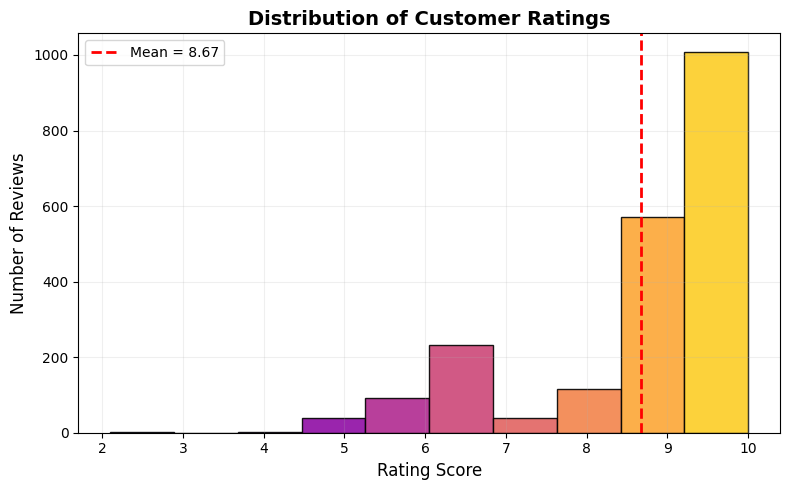

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

scores = df["ReviewScore"]

counts, bins, patches = plt.hist(
    scores,
    bins=10,
    edgecolor="black",
    alpha=0.9
)

for i in range(len(patches)):
    patches[i].set_facecolor(plt.cm.plasma(i / len(patches)))

mean_score = scores.mean()
plt.axvline(mean_score,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean = {mean_score:.2f}")

plt.title("Distribution of Customer Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating Score", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

## **Data Preprocessing**

In [5]:
pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.8 MB/s eta 0:00:00


In [6]:
import pandas as pd
import re
from underthesea import word_tokenize

**Drop invalid variables**

In [7]:
import pandas as pd

cols_to_drop = [
    "STT",
    "productType",
    "reviewer",
    "reviewTimestamp",
    "reviewMaxScore",
    "reviewOriginalText",
    "translationStatus",
    "translationProviderLabelUrl",
    "reviewMedia",
    "reviewReply",
    "reviewAdditionalInformation",
    "subRatingInformations",
    "reactionSummary",
    "reviewOrigin",
    "reviewProvider",
    "reviewOriginLabel",
    "reviewIconUrl"
]

df_droped = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

display(df_droped.head())


,reviewId,ReviewScore,reviewContentText
0,1856073066124162992,10.0,"nhân viên rất nhiệt tình, phòng sạch sẽ, buffe..."
1,1855265970105368446,9.4,Chăm sóc khách hàng thân thiện và chuyên nghiệp!
2,1855075484958738747,10.0,Nhân viên thân thiện và nhiệt tình
3,1854849274851903803,10.0,"Phòng đẹp và view đẹp, giường êm mát, tiện ích..."
4,1854529681735302882,10.0,Một địa điểm tuyệt vời để đi du lịch. Mọi thứ ...


In [8]:
df_droped.to_excel("PCCV_droped.xlsx", index=False)

In [9]:
pip install transformers sentencepiece torch


In [10]:
df = pd.read_excel("/content/PCCV_droped.xlsx")

**Translate into Vietnamese**

In [11]:
!pip install langdetect
!pip install emoji
!pip install deep_translator
import pandas as pd
import unicodedata
import re
import emoji
from deep_translator import GoogleTranslator
from langdetect import detect

def translate_if_needed(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return ""

        text = str(text)
        # detect language
        lang = detect(text)

        if lang != "vi":
            return GoogleTranslator(source='auto', target='vi').translate(text)
        else:
            return text

    except:
        return text

df["review_vi"] = df["reviewContentText"].apply(translate_if_needed)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=aed1fcc2e3bf0700b14a4866355bb490848921cb393335a1f456d2ac994e03f2
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.5 MB/s eta 0:00:00


**Handling duplicate data, emojis and teen code**

In [12]:
#Unicode normalization
def normalize_unicode(text):
    return unicodedata.normalize("NFC", str(text))

In [13]:
#Convert emoji
def convert_emoji(text):
    return emoji.demojize(text)

In [14]:
#Teen code dictionary
teen_dict =  {
    "ko": "không",
    "hok": "không",
    "k": "không",
    "dc": "được",
    "vs": "với",
    "j": "gì",
    "mk": "mình",
    "cx": "cũng",
    "ntn": "như thế nào",
    "ok": "đồng ý",
    "oke": "đồng ý",
    "tks": "cảm ơn",
    "thx": "cảm ơn",
    "thanks": "cảm ơn",
    "sr": "xin lỗi",
    "nv": "nhân viên",
    "pv": "phục vụ",
    "ks": "khách sạn",
    "ph": "phòng",
    "wc": "nhà vệ sinh",
    "dv": "dịch vụ",
    "tp": "thành phố",
    "cf": "cà phê",
    "bf": "buffet",
    "iu": "yêu",
    "z": "vậy",
    "dz": "vậy",
    "hj": "hi",
    "ng": "người",
    "ngta": "người ta",
    "ms": "mới",
    "qa": "quá",
    "gr": "giá rẻ"
}

In [15]:
print(f"Original DataFrame shape: {df.shape}")

initial_rows = df.shape[0]
df.drop_duplicates(subset=['review_vi'], inplace=True)
duplicate_rows_removed = initial_rows - df.shape[0]

print(f"Number of duplicate rows removed: {duplicate_rows_removed}")
print(f"New DataFrame shape after removing duplicates: {df.shape}")

Original DataFrame shape: (2103, 4)
Number of duplicate rows removed: 9
New DataFrame shape after removing duplicates: (2094, 4)


In [16]:
def normalize_teencode(text):
    words = text.split()
    words = [teen_dict.get(word,word) for word in words]
    return " ".join(words)

In [17]:
#Remove repeated characters
def remove_repeated_chars(text):
    text = re.sub(r'(.)\1+', r'\1', text)
    return text

#Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-ZÀ-ỹ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [18]:
def preprocess_text(text):
    text = normalize_unicode(text)
    text = convert_emoji(text)
    text = clean_text(text)
    text = normalize_teencode(text)
    text = remove_repeated_chars(text)
    return text

In [19]:
df["review_clean"] = df["review_vi"].apply(preprocess_text)
display(df.head())

,reviewId,ReviewScore,reviewContentText,review_vi,review_clean
0,1856073066124162992,10.0,"nhân viên rất nhiệt tình, phòng sạch sẽ, buffe...","nhân viên rất nhiệt tình, phòng sạch sẽ, buffe...",nhân viên rất nhiệt tình phòng sạch sẽ bufet n...
1,1855265970105368446,9.4,Chăm sóc khách hàng thân thiện và chuyên nghiệp!,Chăm sóc khách hàng thân thiện và chuyên nghiệp!,chăm sóc khách hàng thân thiện và chuyên nghiệp
2,1855075484958738747,10.0,Nhân viên thân thiện và nhiệt tình,Nhân viên thân thiện và nhiệt tình,nhân viên thân thiện và nhiệt tình
3,1854849274851903803,10.0,"Phòng đẹp và view đẹp, giường êm mát, tiện ích...","Phòng đẹp và view đẹp, giường êm mát, tiện ích...",phòng đẹp và view đẹp giường êm mát tiện ích t...
4,1854529681735302882,10.0,Một địa điểm tuyệt vời để đi du lịch. Mọi thứ ...,Một địa điểm tuyệt vời để đi du lịch. Mọi thứ ...,một địa điểm tuyệt vời để đi du lịch mọi thứ đ...


In [20]:
df.to_excel("PCCV_processed_data.xlsx", index=False)

**Stopword Removal**

In [21]:
pip install scikit-learn

In [22]:
pip install underthesea

In [23]:
from underthesea import word_tokenize

In [24]:
pip install nltk


In [25]:
import nltk
import pandas as pd
import re
from underthesea import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

vietnamese_stopwords_list = [
    "là", "mà", "thì", "và", "của", "này", "ấy", "nhỉ", "nhé",
    "cho", "để", "cái", "con", "những", "tại", "với", "vậy",
    "a", "còn", "có", "khi", "không", "là", "lại", "và", "với", "đã", "đang", "được", "đi",
    "bị", "bởi", "cả", "các", "cái", "chỉ", "chiếc", "cho", "chứ", "chợt", "chưa", "chuyện",
    "dành", "do", "dưới", "đúng", "hết", "hay", "kể", "khiến", "làm", "mà", "mỗi", "một",
    "muốn", "nếu", "như", "nhưng", "những", "phải", "qua", "ra", "rất", "rồi", "sau", "sẽ",
    "từ", "từng", "trên", "trong", "trước", "vẫn", "vào", "vậy", "việc", "vì", "vừa", "về"
]

df = pd.read_excel("/content/PCCV_processed_data.xlsx")

def preprocess_vietnamese_text(text, stopwords_set):
    if not isinstance(text, str):
        return ""

    text_tokenized = word_tokenize(text, format="text")
    tokens = text_tokenized.split()
    stopwords_set_underthesea_format = set([w.replace(' ', '_') for w in stopwords_set])
    filtered_tokens = [word for word in tokens if word not in stopwords_set_underthesea_format]
    return " ".join(filtered_tokens)

stop_words_underthesea_format = set([w.replace(' ', '_') for w in vietnamese_stopwords_list])

df['processed_content'] = df['review_clean'].apply(
    lambda x: preprocess_vietnamese_text(x, stop_words_underthesea_format)
)

print(df[['review_clean', 'processed_content']].head())
df.to_excel("PCCV_PTDLW_stopwords_removed.xlsx", index=False)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                        review_clean  \
0  nhân viên rất nhiệt tình phòng sạch sẽ bufet n...   
1    chăm sóc khách hàng thân thiện và chuyên nghiệp   
2                 nhân viên thân thiện và nhiệt tình   
3  phòng đẹp và view đẹp giường êm mát tiện ích t...   
4  một địa điểm tuyệt vời để đi du lịch mọi thứ đ...   

                                   processed_content  
0  nhân_viên nhiệt_tình phòng sạch_sẽ bufet nhiều...  
1       chăm_sóc khách_hàng thân_thiện chuyên_nghiệp  
2                    nhân_viên thân_thiện nhiệt_tình  
3  phòng đẹp view đẹp giường êm_mát tiện_ích tốt ...  
4  địa_điểm tuyệt_vời du_lịch mọi thứ đều tốt tất...  


**Text Representation Using TF-IDF**

In [26]:
import pandas as pd

In [27]:
df = pd.read_excel("/content/PCCV_PTDLW_stopwords_removed.xlsx")

In [28]:
#Labeling
def label_review(score):
    if score >= 9:
        return 1
    else:
        return 0

df["label"] = df["ReviewScore"].apply(label_review)
df["label"].value_counts()

,count
label,
1,1127
0,967


In [29]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=0.95,
    ngram_range=(1,2)
)

# Fill NaN values with empty strings before vectorizing
X = vectorizer.fit_transform(df["processed_content"].fillna(""))
y = df["label"]

print("TF-IDF shape:", X.shape)

TF-IDF shape: (2094, 30925)


# **MODEL DEVELOPMENT AND EVALUATION**

##**Support Vector Machine Model**



**Train–Test Split**

In [30]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

**Model Development**

In [31]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight="balanced")
svm_model.fit(X_train, y_train)

LinearSVC(class_weight='balanced')

In [32]:
from sklearn.metrics import classification_report
print("=== SVM ===")
y_pred_svm = svm_model.predict(X_test)
print(classification_report(
    y_test, y_pred_svm,
    target_names=["negative", "positive"]
))

=== SVM ===
              precision    recall  f1-score   support

    negative       0.70      0.68      0.69       193
    positive       0.73      0.76      0.75       226

    accuracy                           0.72       419
   macro avg       0.72      0.72      0.72       419
weighted avg       0.72      0.72      0.72       419



**Confusion Matrix**

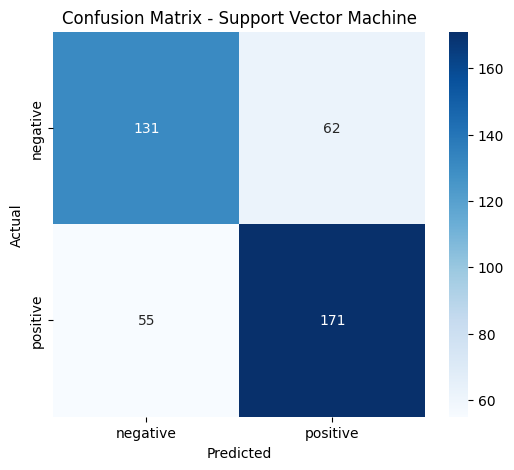

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_logistic = svm_model.predict(X_test)
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

##**PhoBert Model**

In [34]:
import pandas as pd
import numpy as np
import torch
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [35]:
df = pd.read_excel("/content/PCCV_processed_data.xlsx")


In [36]:
#Labeling
def label_sentiment(score):
    if score >= 9:
        return "positive"
    else:
        return "negative"

df["sentiment"] = df["ReviewScore"].apply(label_sentiment)


In [37]:
# Label Encoding
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

In [39]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def tokenize_function(examples):
    return tokenizer(
        examples["review_clean"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

In [40]:
from torch.nn import CrossEntropyLoss

In [41]:
#Training configuration
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [42]:
# Stratified K-Fold cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = []

In [1]:
# GPU availability check
from torch.nn import CrossEntropyLoss
import torch
print(torch.cuda.is_available())

True


**Model Training**

In [45]:
from sklearn.metrics import accuracy_score, f1_score, recall_score
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss
from transformers import Trainer, AutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset

# Custom trainer with class Weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if hasattr(self, 'class_weights') and self.class_weights is not None:
            loss_fct = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fct = CrossEntropyLoss()
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Initialization of evaluation metrics storage
fold_accuracies = []
fold_f1s = []
fold_recalls = []

# Stratified K-Fold cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["label"])):
    print(f"\n========== Fold: {fold} ==========")
    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()
    train_df['review_clean'] = train_df['review_clean'].fillna('')
    val_df['review_clean'] = val_df['review_clean'].fillna('')
    train_dataset = Dataset.from_pandas(train_df[['review_clean','label']])
    val_dataset = Dataset.from_pandas(val_df[['review_clean','label']])
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
    val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
   # Model initialization
    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/phobert-base",
        num_labels=len(np.unique(df["label"]))
    )
    classes = np.unique(train_df["label"])
    class_weights_np = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=train_df["label"]
    )
    class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32)

    # Trainer initialization with Class Weights
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )
    trainer.class_weights = class_weights_tensor

    # Model training
    trainer.train()
    preds = trainer.predict(val_dataset)
    probs = F.softmax(torch.tensor(preds.predictions), dim=1).numpy()
    best_f1 = 0
    best_t = 0.5
    true_labels = val_df["label"].values

    for t in [0.4, 0.5, 0.6, 0.7]:
        temp_preds = (probs[:,1] > t).astype(int)
        score = f1_score(true_labels, temp_preds, average="binary")
        if score > best_f1:
            best_f1 = score
            best_t = t
    # Final prediction assignment
    pred_labels = (probs[:,1] > best_t).astype(int)
    df.loc[val_idx, "pred_label"] = pred_labels
    # Model evaluation metrics calculation
    acc = accuracy_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels, average="binary")
    recall = recall_score(true_labels, pred_labels, average="binary")

    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    fold_recalls.append(recall)

    print(f"-> Fold {fold} Kết quả: Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | Recall: {recall:.4f}")

print("\n========== TỔNG KẾT SAU KHI CHẠY XONG K-FOLD ==========")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-Score: {np.mean(fold_f1s):.4f}")
print(f"Mean Recall:   {np.mean(fold_recalls):.4f}")


========== Fold: 0 ==========


Map:   0%|          | 0/1675 [00:00<?, ? examples/s]

Map:   0%|          | 0/419 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Map:   0%|          | 0/418 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

Epoch,Training Loss,Validation Loss
1,No log,0.542808
2,No log,0.530995
3,0.566014,0.534745
4,0.566014,0.541969


-> Fold 4 Kết quả: Accuracy: 0.7560 | F1-Score: 0.7984 | Recall: 0.8978

========== TỔNG KẾT SAU KHI CHẠY XONG K-FOLD ==========
Mean Accuracy: 0.7531
Mean F1-Score: 0.7921
Mean Recall:   0.8740


**Save model**

In [47]:
trainer.save_model("/content/phobert_model")
tokenizer.save_pretrained("/content/phobert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/phobert_model/tokenizer_config.json',
 '/content/phobert_model/vocab.txt',
 '/content/phobert_model/bpe.codes',
 '/content/phobert_model/added_tokens.json')

In [48]:
df.to_excel("/content/processed_data.xlsx", index=False)

In [49]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/phobert_model /content/drive/MyDrive/

Mounted at /content/drive


In [50]:
# Load model
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/phobert_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

#**MAPING ASPECTS**

In [51]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.1 MB/s eta 0:00:00


**Negative review extraction**

In [79]:
df_neg = df[df["pred_label"] == 0].copy()
texts = df_neg["review_clean"].astype(str).tolist()
print(f"Số lượng đánh giá tiêu cực: {len(texts)}")
print(f"Kiểu dữ liệu phần tử đầu tiên: {type(texts[0])}")

Số lượng đánh giá tiêu cực: 734
Kiểu dữ liệu phần tử đầu tiên: <class 'str'>


**Topic modeling using BERTopic**

In [80]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=5,
    nr_topics="10"
)

topics, probs = topic_model.fit_transform(texts)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [81]:
stopwords = [
    "không", "có", "là", "mình", "thì", "rất",
    "và", "cũng", "nhưng", "được", "bị"
]

def clean_words(topic_id):
    words_scores = topic_model.get_topic(topic_id)
    words = [
        w for w, s in words_scores
        if s > 0.03 and w not in stopwords and len(w) > 2
    ]

    return words[:10]

In [82]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\b(the|is|and|to|was)\b", "", text)
    return text

df_neg["clean_topic"] = df_neg["review_clean"].apply(clean_text)

**Aspect mapping**

In [83]:
from sentence_transformers import util

aspect_labels = [
    "Facilities",
    "Amenities",
    "Cleanliness",
    "Food",
    "Staff&Service"
]
aspect_embeddings = embedding_model.encode(aspect_labels, convert_to_tensor=True)

def map_topic_semantic(words):
    text = " ".join(words)
    topic_embedding = embedding_model.encode(text, convert_to_tensor=True)
    scores = util.cos_sim(topic_embedding, aspect_embeddings)
    best_idx = scores.argmax()
    return aspect_labels[best_idx]

**Topic-Aspect mapping results**

In [84]:
topic_data = []

for topic_id in topic_model.get_topics():
    if topic_id == -1:
        continue
    words = clean_words(topic_id)
    if len(words) == 0:
        continue

    topic_data.append({
        "Topic": topic_id,
        "Keywords": ", ".join(words),
        "Aspect": map_topic_semantic(words)
    })

df_topics = pd.DataFrame(topic_data)
df_topics

,Topic,Keywords,Aspect
0,0,phòng,Facilities
1,1,"bơi, nhỏ",Amenities
2,2,"nhan, khach, khong, san, vien, phong, sach, tot",Amenities
3,3,khách,Facilities
4,4,check,Amenities
5,5,"sáng, khách, sạn",Facilities
6,6,sáng,Amenities
7,7,"sạn, khách, cấp",Facilities
8,8,"món, ngon, sáng, bữa",Food
9,9,"viên, nhân, hàng, tân, check, thái, cười",Staff&Service


**Word cloud visualization**

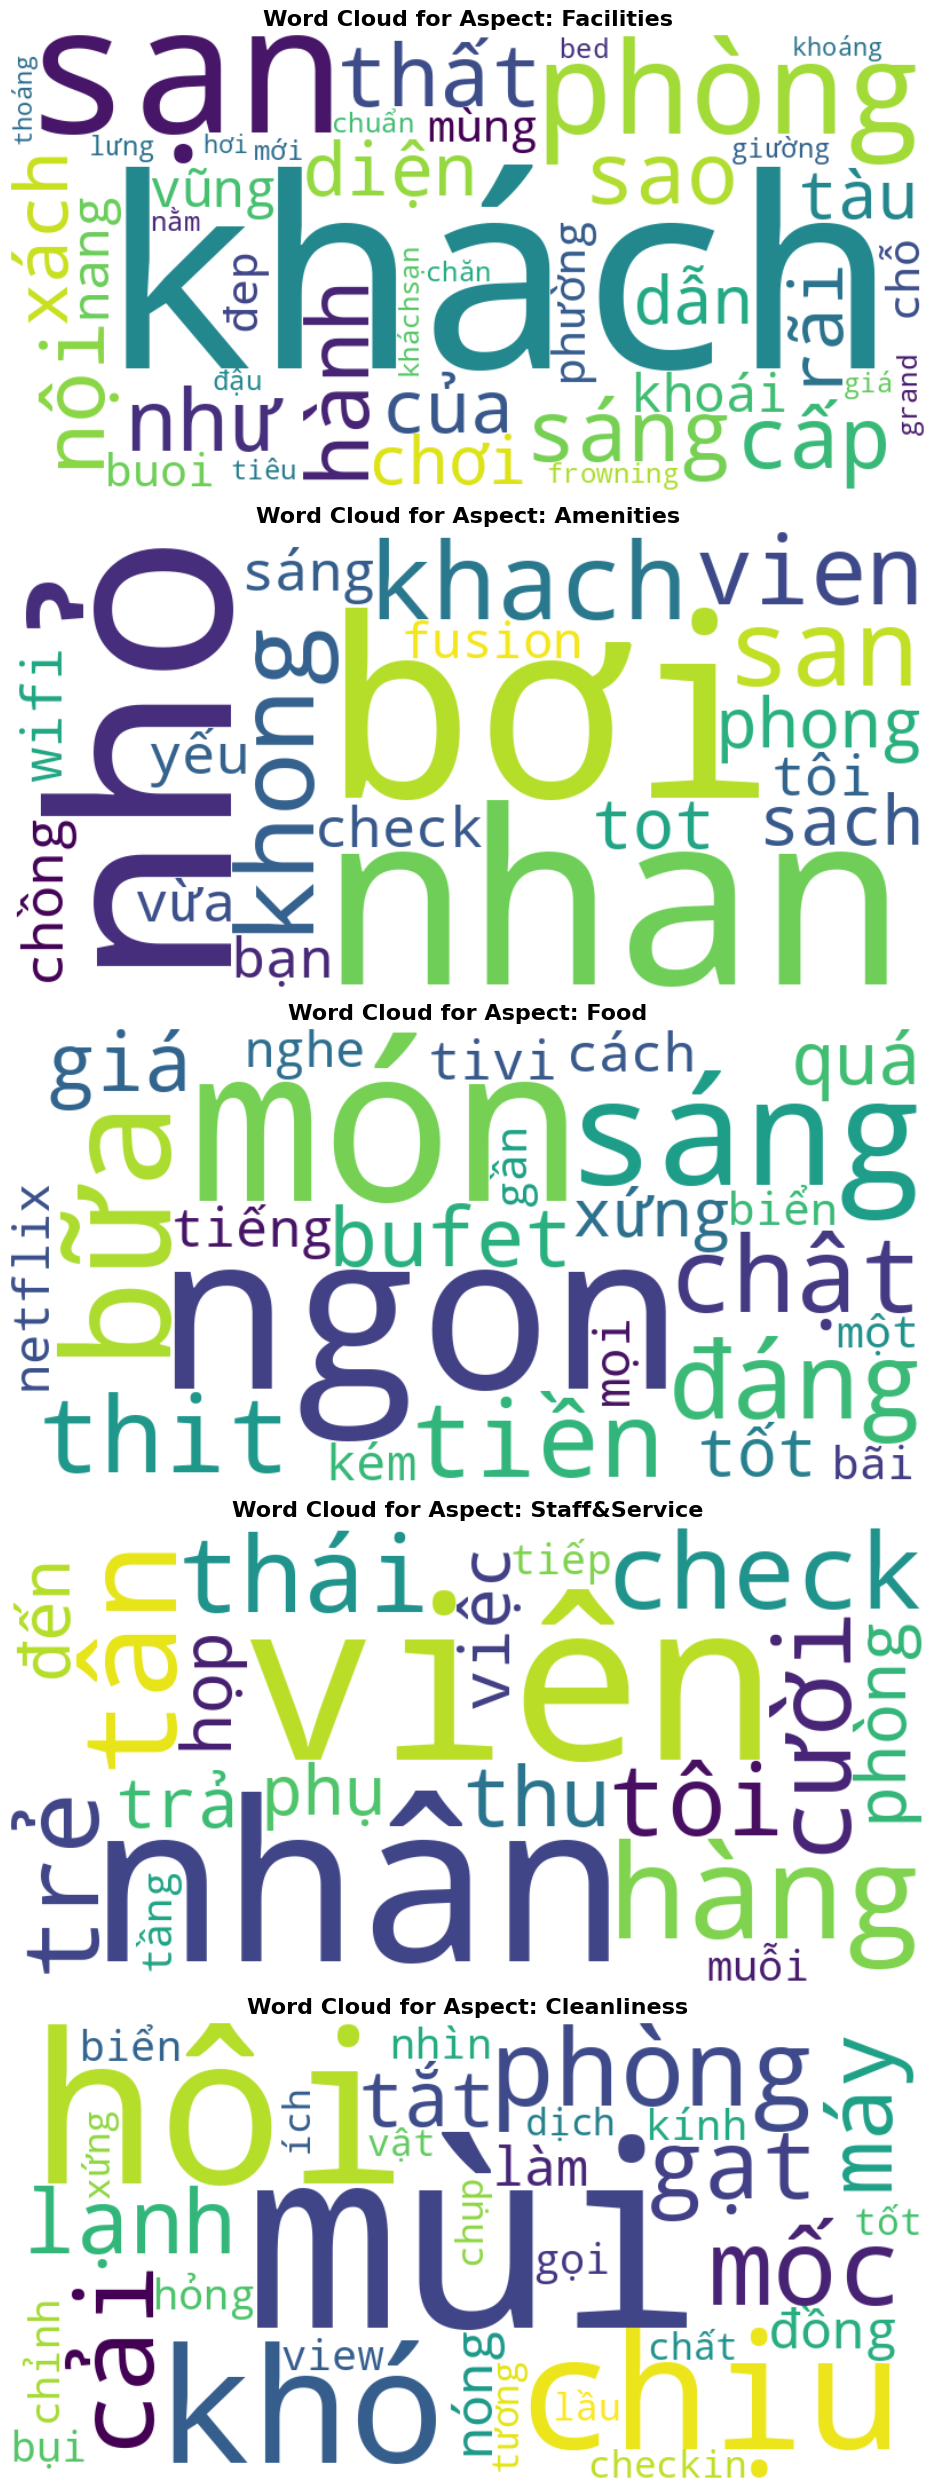

In [85]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get unique aspects
unique_aspects = df_topics['Aspect'].unique()

fig, axes = plt.subplots(nrows=len(unique_aspects), ncols=1, figsize=(10, 5 * len(unique_aspects)))
if len(unique_aspects) == 1:
    axes = [axes]

for i, aspect in enumerate(unique_aspects):
    text = " ".join(df_topics[df_topics['Aspect'] == aspect]['Keywords'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Word Cloud for Aspect: {aspect}", fontsize=16, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Aspect distribution**

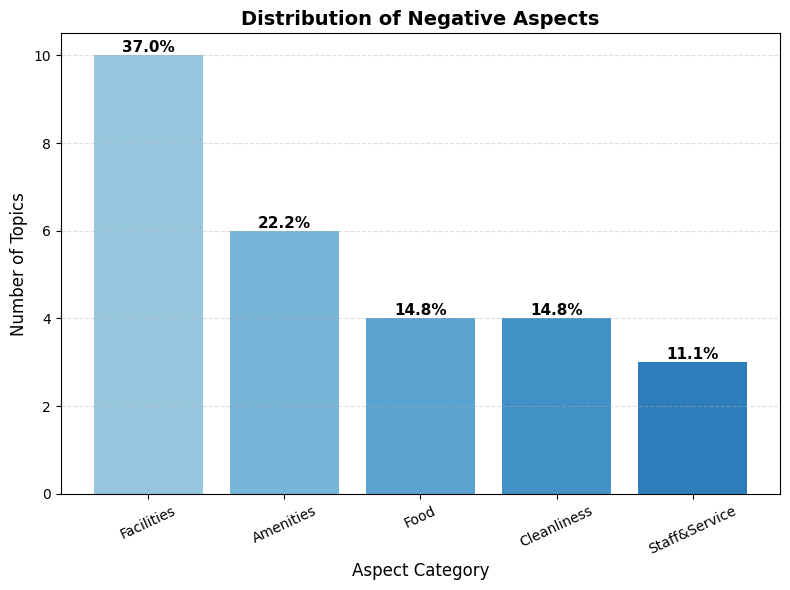

In [86]:
import matplotlib.pyplot as plt

aspect_counts = df_topics["Aspect"].value_counts()
aspect_percent = aspect_counts / aspect_counts.sum() * 100

plt.figure(figsize=(8,6))
colors = plt.cm.Blues(range(100, 100 + 20*len(aspect_counts), 20))
bars = plt.bar(
    aspect_counts.index,
    aspect_counts.values,
    color=colors
)

for i, bar in enumerate(bars):
    height = bar.get_height()
    percent = aspect_percent.iloc[i]
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{percent:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribution of Negative Aspects", fontsize=14, fontweight='bold')
plt.xlabel("Aspect Category", fontsize=12)
plt.ylabel("Number of Topics", fontsize=12)
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()